# Enriched Injury-Risk Model — StatsBomb Event Features

**Context:** In [task.ipynb](task.ipynb) we built a 14-day injury prediction baseline using Transfermarkt appearances + injuries. The model achieved ROC-AUC ~0.68 but very low AUPRC (~0.05), limited by **feature poverty** — minutes played is a coarse workload proxy.

**This notebook** enriches the pipeline with **StatsBomb event-derived intensity features** — pressures received, duels contested, fouls suffered, high-intensity carries, sprints — as a proof-of-concept for what richer data adds.

**Coverage:** StatsBomb provides free event data for **2015/16 across 5 major leagues** (La Liga, Premier League, Serie A, Ligue 1, Bundesliga — ~1,800 matches). We focus on this season as the densest overlap window.

**Join strategy:** StatsBomb uses its own player IDs. We join to Transfermarkt via **player name + team + match date** fuzzy matching.

**Governance note:** Same as task.ipynb — health-sensitive data, research prototype only.

In [1]:
# ── Imports & paths ──────────────────────────────────────────────────
import warnings, pathlib, json, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from collections import defaultdict
from bisect import bisect_right

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
)
from sklearn.calibration import calibration_curve
import lightgbm as lgb

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA = pathlib.Path("../data")
SB_DATA = DATA / "open-data/data"
print("Setup complete.")

Setup complete.


---
## A. Parse StatsBomb Events into Player-Match Features

For each player in each match, we extract intensity proxies from event data:
- **Pressures applied** — high defensive work rate
- **Duels contested** — physical engagements
- **Fouls committed / suffered** — contact exposure
- **Carries** (total + distance) — ball-carrying load
- **Passes** (total count) — involvement intensity
- **Shots** — offensive load
- **Ball recoveries** — defensive effort
- **Dribbles attempted** — 1v1 exertion

In [2]:
# ── A1. Identify target matches (2015/16, 5 major leagues) ───────────
target_comps = {
    (11, 27),   # La Liga 2015/16
    (2, 27),    # Premier League 2015/16
    (12, 27),   # Serie A 2015/16
    (7, 27),    # Ligue 1 2015/16
    (9, 27),    # Bundesliga 2015/16
}

# Load match metadata to get match_id → date mapping
match_meta = {}  # match_id → {date, home_team, away_team, competition}
match_ids = []

for comp_dir in os.listdir(SB_DATA / "matches"):
    match_dir = SB_DATA / "matches" / comp_dir
    if not match_dir.is_dir():
        continue
    for mf in os.listdir(match_dir):
        if not mf.endswith(".json"):
            continue
        with open(match_dir / mf) as f:
            matches = json.load(f)
        for m in matches:
            cid = m["competition"]["competition_id"]
            sid = m["season"]["season_id"]
            if (cid, sid) in target_comps:
                mid = m["match_id"]
                match_meta[mid] = {
                    "match_date": m["match_date"],
                    "home_team": m["home_team"]["home_team_name"],
                    "away_team": m["away_team"]["away_team_name"],
                    "competition": m["competition"]["competition_name"],
                }
                match_ids.append(mid)

print(f"Target matches (2015/16, 5 leagues): {len(match_ids)}")
# Show distribution
from collections import Counter
comp_counts = Counter(v["competition"] for v in match_meta.values())
for c, n in comp_counts.most_common():
    print(f"  {c}: {n} matches")

Target matches (2015/16, 5 leagues): 1823
  La Liga: 380 matches
  Serie A: 380 matches
  Premier League: 380 matches
  Ligue 1: 377 matches
  1. Bundesliga: 306 matches


In [3]:
# ── A2. Parse events → player-match intensity features ───────────────
# For each match, aggregate events per player into intensity proxies.

def compute_carry_distance(carry_obj, location):
    """Compute carry distance from location to end_location."""
    if carry_obj and "end_location" in carry_obj and location:
        try:
            dx = carry_obj["end_location"][0] - location[0]
            dy = carry_obj["end_location"][1] - location[1]
            return (dx**2 + dy**2) ** 0.5
        except (TypeError, IndexError):
            pass
    return 0.0

rows = []
processed = 0
missing = 0

for mid in match_ids:
    event_file = SB_DATA / "events" / f"{mid}.json"
    if not event_file.exists():
        missing += 1
        continue
    
    with open(event_file) as f:
        events = json.load(f)
    
    meta = match_meta[mid]
    
    # Aggregate per player
    player_stats = defaultdict(lambda: {
        "pressures": 0, "duels": 0, "fouls_committed": 0, "fouls_won": 0,
        "carries": 0, "carry_distance": 0.0, "passes": 0, "shots": 0,
        "ball_recoveries": 0, "dribbles": 0, "dribbled_past": 0,
        "clearances": 0, "interceptions": 0, "blocks": 0,
        "team": None, "player_name": None,
    })
    
    for evt in events:
        player = evt.get("player")
        if not player:
            continue
        
        pid = player["id"]
        pname = player["name"]
        team = evt.get("team", {}).get("name", "")
        etype = evt.get("type", {}).get("name", "")
        
        ps = player_stats[pid]
        ps["player_name"] = pname
        ps["team"] = team
        
        if etype == "Pressure":
            ps["pressures"] += 1
        elif etype == "Duel":
            ps["duels"] += 1
        elif etype == "Foul Committed":
            ps["fouls_committed"] += 1
        elif etype == "Foul Won":
            ps["fouls_won"] += 1
        elif etype == "Carry":
            ps["carries"] += 1
            ps["carry_distance"] += compute_carry_distance(
                evt.get("carry"), evt.get("location")
            )
        elif etype == "Pass":
            ps["passes"] += 1
        elif etype == "Shot":
            ps["shots"] += 1
        elif etype == "Ball Recovery":
            ps["ball_recoveries"] += 1
        elif etype == "Dribble":
            ps["dribbles"] += 1
        elif etype == "Dribbled Past":
            ps["dribbled_past"] += 1
        elif etype == "Clearance":
            ps["clearances"] += 1
        elif etype == "Interception":
            ps["interceptions"] += 1
        elif etype == "Block":
            ps["blocks"] += 1
    
    for pid, stats in player_stats.items():
        rows.append({
            "sb_match_id": mid,
            "sb_player_id": pid,
            "sb_player_name": stats["player_name"],
            "sb_team": stats["team"],
            "match_date": meta["match_date"],
            "home_team": meta["home_team"],
            "away_team": meta["away_team"],
            "competition": meta["competition"],
            **{k: v for k, v in stats.items() if k not in ("player_name", "team")},
        })
    
    processed += 1

sb_features = pd.DataFrame(rows)
sb_features["match_date"] = pd.to_datetime(sb_features["match_date"])

print(f"Parsed {processed} matches ({missing} missing event files)")
print(f"Player-match rows: {len(sb_features):,}")
print(f"Unique players:    {sb_features.sb_player_id.nunique():,}")
print(f"\nFeature summary:")
display(sb_features.describe().T[["mean", "std", "min", "max"]])

Parsed 1823 matches (0 missing event files)
Player-match rows: 50,503
Unique players:    2,635

Feature summary:


,mean,std,min,max
sb_match_id,3780858.031028,476366.210024,265839.0,3901263.0
sb_player_id,19247.842524,56730.155269,2936.0,403392.0
match_date,2016-01-02 19:33:42.937251328,NaN,2015-08-07 00:00:00,2016-05-17 00:00:00
pressures,11.804823,8.670771,0.0,73.0
duels,2.989981,2.599335,0.0,23.0
fouls_committed,1.096153,1.239387,0.0,9.0
fouls_won,1.044215,1.2742,0.0,13.0
carries,26.421916,17.497809,0.0,178.0
carry_distance,157.567105,114.992577,0.0,932.423504
passes,35.194186,21.829338,0.0,204.0


---
## B. Join StatsBomb Features to Transfermarkt Appearances

StatsBomb uses its own player IDs. We join on **normalized player name + match date** (exact date match). This is a conservative strategy — only exact name+date matches count. Some players will be lost due to name transliteration differences.

In [4]:
# ── B1. Load Transfermarkt data (same as task.ipynb) ─────────────────
appearances = pd.read_csv(DATA / "transfermarkt-datasets/appearances.csv.gz")
injuries    = pd.read_csv(DATA / "transfermarkt/player_injuries/player_injuries.csv")
players     = pd.read_csv(DATA / "transfermarkt-datasets/players.csv.gz")
games       = pd.read_csv(DATA / "transfermarkt-datasets/games.csv.gz")

appearances["date"] = pd.to_datetime(appearances["date"])
injuries["from_date"] = pd.to_datetime(injuries["from_date"], errors="coerce")
injuries["end_date"] = pd.to_datetime(injuries["end_date"], errors="coerce")
players["date_of_birth"] = pd.to_datetime(players["date_of_birth"], errors="coerce")
games["date"] = pd.to_datetime(games["date"], errors="coerce")

# Filter to overlapping players
overlap_ids = set(appearances.player_id.unique()) & set(injuries.player_id.unique())
app = appearances[appearances.player_id.isin(overlap_ids)].copy()

# Focus on 2015/16 season window (Aug 2015 – Jun 2016) for the enriched model
app_season = app[(app.date >= "2015-08-01") & (app.date <= "2016-06-30")].copy()
print(f"Transfermarkt appearances in 2015/16 window: {len(app_season):,}")
print(f"  Players: {app_season.player_id.nunique():,}")
print(f"  Date range: {app_season.date.min().date()} → {app_season.date.max().date()}")

Transfermarkt appearances in 2015/16 window: 101,406
  Players: 4,838
  Date range: 2015-08-01 → 2016-06-30


In [5]:
# ── B2. Name normalization & join ────────────────────────────────────
import unicodedata, re

def normalize_name(name):
    """Normalize player name for fuzzy matching: strip accents, lowercase, collapse whitespace."""
    if pd.isna(name):
        return ""
    # Decompose unicode and strip combining characters (accents)
    name = unicodedata.normalize("NFKD", str(name))
    name = "".join(c for c in name if not unicodedata.combining(c))
    name = name.lower().strip()
    name = re.sub(r"\s+", " ", name)
    return name

# Normalize names in both datasets
sb_features["name_norm"] = sb_features["sb_player_name"].apply(normalize_name)
app_season["name_norm"] = app_season["player_name"].apply(normalize_name)

# Create join key: normalized name + date
sb_features["join_key"] = sb_features["name_norm"] + "_" + sb_features["match_date"].dt.strftime("%Y-%m-%d")
app_season["join_key"] = app_season["name_norm"] + "_" + app_season["date"].dt.strftime("%Y-%m-%d")

# StatsBomb event feature columns
SB_FEAT_COLS = [
    "pressures", "duels", "fouls_committed", "fouls_won",
    "carries", "carry_distance", "passes", "shots",
    "ball_recoveries", "dribbles", "dribbled_past",
    "clearances", "interceptions", "blocks",
]

# Join
sb_join = sb_features[["join_key"] + SB_FEAT_COLS].drop_duplicates(subset="join_key")
enriched = app_season.merge(sb_join, on="join_key", how="left")

n_matched = enriched[SB_FEAT_COLS[0]].notna().sum()
print(f"=== Join results ===")
print(f"  Transfermarkt rows:       {len(app_season):,}")
print(f"  StatsBomb feature rows:   {len(sb_join):,}")
print(f"  Matched (inner):          {n_matched:,} ({n_matched/len(enriched)*100:.1f}%)")
print(f"  Unmatched:                {len(enriched) - n_matched:,}")
print(f"  Unique matched players:   {enriched.loc[enriched[SB_FEAT_COLS[0]].notna(), 'player_id'].nunique():,}")

=== Join results ===
  Transfermarkt rows:       101,406
  StatsBomb feature rows:   50,503
  Matched (inner):          27,247 (26.9%)
  Unmatched:                74,159
  Unique matched players:   1,393


---
## C. Data Preparation — Discrete-Time Survival Dataset

**Modeling reformulation:** Instead of binary "injury in 14 days?", we build a **discrete-time hazard model**.

For each player-appearance (reference date), we expand into 14 rows (day +1 through day +14). Each row gets:
- **target**: 1 if the injury starts on that exact future day, 0 otherwise
- **horizon_day**: which day ahead (1–14)
- **all features** from the reference date (backward-looking only)
- **StatsBomb intensity features** where matched

This gives us a daily hazard estimate: P(injury on day t+k | no injury before t+k, features at t).

The 14-day cumulative risk is then: 1 − ∏(1 − ĥ_k) for k = 1..14.

In [6]:
# ── C1. Build injury label + target injury set ──────────────────────
target_keywords = [
    "hamstring", "groin", "adductor", "calf",
    "thigh", "muscle injury", "muscular problems",
    "muscle fatigue", "torn muscle fiber", "muscle",
]

def is_target_injury(reason):
    if pd.isna(reason):
        return False
    return any(kw in reason.lower() for kw in target_keywords)

injuries["is_target_injury"] = injuries["injury_reason"].apply(is_target_injury)
inj = injuries[injuries.player_id.isin(overlap_ids)].copy()
inj_target = inj[inj.is_target_injury].dropna(subset=["from_date"]).copy()

# Build sorted injury date lookup per player
inj_dates_by_player = (
    inj_target.groupby("player_id")["from_date"]
    .apply(lambda s: sorted(s.tolist()))
    .to_dict()
)

# Also build full injury history for feature engineering
all_inj = inj.dropna(subset=["from_date"]).copy()
target_inj_by_player = inj_target.groupby("player_id").apply(
    lambda g: list(zip(g["from_date"], g["end_date"], g["days_missed"]))
).to_dict()
all_inj_by_player = all_inj.groupby("player_id").apply(
    lambda g: list(zip(g["from_date"], g["end_date"], g["days_missed"]))
).to_dict()

print(f"Target injuries: {len(inj_target):,} across {inj_target.player_id.nunique():,} players")

Target injuries: 25,524 across 9,173 players


In [7]:
# ── C2. Rolling workload features ────────────────────────────────────
# Use the full appearance history (not just 2015/16) so rolling windows are populated.
app_full = app.sort_values(["player_id", "date"]).reset_index(drop=True)

windows = [7, 14, 28]

def compute_rolling_features(group):
    g = group.sort_values("date").copy()

    # Pandas can drop group keys inside groupby-apply chunks depending on version.
    # Re-attach player_id explicitly to keep downstream feature engineering stable.
    if "player_id" not in g.columns:
        g["player_id"] = group.name

    dates = g["date"].values
    mins = g["minutes_played"].values

    for w in windows:
        roll_mins = np.zeros(len(g))
        roll_matches = np.zeros(len(g))
        for i in range(len(g)):
            cutoff = dates[i] - np.timedelta64(w, "D")
            mask = (dates[:i] > cutoff) & (dates[:i] <= dates[i])
            roll_mins[i] = mins[:i][mask].sum()
            roll_matches[i] = mask.sum()
        g[f"mins_last_{w}d"] = roll_mins
        g[f"matches_last_{w}d"] = roll_matches
        g[f"avg_mins_last_{w}d"] = np.where(roll_matches > 0, roll_mins / roll_matches, 0)

    g["days_since_last_match"] = g["date"].diff().dt.days.fillna(30).clip(upper=90)
    g["cum_matches_season"] = g.groupby(g["date"].dt.year).cumcount()
    return g

print("Computing rolling features on full history...")
app_full = app_full.groupby("player_id", group_keys=False).apply(compute_rolling_features)
app_full = app_full.reset_index(drop=True)

# Final safety check for downstream cells.
if "player_id" not in app_full.columns and "player_id" in app_full.index.names:
    app_full = app_full.reset_index()

print(f"Done. Full appearances shape: {app_full.shape}")
print(f"player_id column present: {'player_id' in app_full.columns}")

# Now filter to the 2015/16 season for the enriched model
app_s = app_full[(app_full.date >= "2015-08-01") & (app_full.date <= "2016-06-30")].copy()
print(f"2015/16 season appearances: {len(app_s):,}")

Computing rolling features on full history...


Done. Full appearances shape: (1418820, 24)
player_id column present: True
2015/16 season appearances: 101,406


In [8]:
# ── C3. Injury history features ──────────────────────────────────────
def _ensure_core_columns(df):
    """Make C3 robust to notebook re-runs where keys may end up in index/suffixed names."""
    out = df.copy()

    # Recover key columns if they became index levels.
    idx_names = [n for n in out.index.names if n is not None]
    if "player_id" in idx_names or "date" in idx_names:
        out = out.reset_index()

    # Handle common merge suffix variants.
    for base in ("player_id", "date"):
        if base not in out.columns:
            for alt in (f"{base}_x", f"{base}_y"):
                if alt in out.columns:
                    out = out.rename(columns={alt: base})
                    break

    missing = [c for c in ("player_id", "date") if c not in out.columns]
    if missing:
        raise KeyError(
            f"Missing required columns {missing}. "
            f"Current columns sample: {list(out.columns)[:20]}"
        )

    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out = out.dropna(subset=["player_id", "date"]).copy()
    return out


def compute_injury_history(df):
    df = _ensure_core_columns(df)

    n = len(df)
    prior_target_injuries = np.zeros(n)
    days_since_last_injury = np.full(n, 365.0)
    recent_return_30d = np.zeros(n, dtype=np.int8)
    injuries_last_365d = np.zeros(n)
    all_injuries_career = np.zeros(n)

    for i, (pid, match_date) in enumerate(zip(df["player_id"].values, df["date"].values)):
        match_date = pd.Timestamp(match_date)

        t_episodes = target_inj_by_player.get(pid, [])
        prior_target_injuries[i] = sum(1 for e in t_episodes if e[0] < match_date)

        ended_before = [e for e in t_episodes if pd.notna(e[1]) and e[1] < match_date]
        if ended_before:
            last_end = max(e[1] for e in ended_before)
            days_since_last_injury[i] = (match_date - last_end).days
            if (match_date - last_end).days <= 30:
                recent_return_30d[i] = 1

        cutoff_365 = match_date - timedelta(days=365)
        injuries_last_365d[i] = sum(1 for e in t_episodes if cutoff_365 <= e[0] < match_date)

        a_episodes = all_inj_by_player.get(pid, [])
        all_injuries_career[i] = sum(1 for e in a_episodes if e[0] < match_date)

    df["prior_target_injuries"] = prior_target_injuries
    df["days_since_last_injury"] = days_since_last_injury.clip(max=730)
    df["recent_return_30d"] = recent_return_30d
    df["target_injuries_last_365d"] = injuries_last_365d
    df["all_injuries_career"] = all_injuries_career
    return df

print("Computing injury history features...")
app_s = compute_injury_history(app_s)
print("Done.")

Computing injury history features...


Done.


In [9]:
# ── C4. Merge demographics + StatsBomb + game context ────────────────
# Player demographics
player_cols = players[["player_id", "date_of_birth", "position", "height_in_cm", "foot"]].drop_duplicates("player_id")
app_s = app_s.merge(player_cols, on="player_id", how="left")
app_s["age_at_match"] = (app_s["date"] - app_s["date_of_birth"]).dt.days / 365.25

# Position / foot encoding
app_s["position_enc"] = app_s["position"].map(
    {"Attack": 0, "Midfield": 1, "Defender": 2, "Goalkeeper": 3}
).fillna(-1).astype(int)
app_s["foot_enc"] = app_s["foot"].map({"right": 0, "left": 1, "both": 2}).fillna(-1).astype(int)

# Competition type from games
game_cols = games[["game_id", "competition_type"]].drop_duplicates("game_id")
app_s = app_s.merge(game_cols, on="game_id", how="left")
app_s["is_domestic_league"] = (app_s["competition_type"] == "domestic_league").astype(int)

# StatsBomb features via name+date join
app_s["name_norm"] = app_s["player_name"].apply(normalize_name)
app_s["join_key"] = app_s["name_norm"] + "_" + app_s["date"].dt.strftime("%Y-%m-%d")
app_s = app_s.merge(sb_join, on="join_key", how="left")

# Fill missing StatsBomb features with 0 (player not in StatsBomb coverage)
app_s["has_sb_data"] = app_s["pressures"].notna().astype(int)
for col in SB_FEAT_COLS:
    app_s[col] = app_s[col].fillna(0)

n_sb = app_s["has_sb_data"].sum()
print(f"Final appearance-level dataset: {len(app_s):,} rows")
print(f"  With StatsBomb features: {n_sb:,} ({n_sb/len(app_s)*100:.1f}%)")
print(f"  Players: {app_s.player_id.nunique():,}")

Final appearance-level dataset: 101,406 rows
  With StatsBomb features: 27,247 (26.9%)
  Players: 4,838


In [10]:
# ── C5. Expand to discrete-time survival rows ───────────────────────
# For each appearance row, create 14 rows (horizon_day 1–14).
# Target: did a target injury start on exactly (date + horizon_day)?
# Censoring: if an injury starts on day k, rows for days k+1..14 are dropped
#            (player is "out of risk set" after event).

HORIZON = 14


def ensure_appearance_features(df):
    """Make C5 robust if C4 was skipped or partially executed."""
    out = df.copy()

    required = {
        "age_at_match", "height_in_cm", "position_enc", "foot_enc",
        "is_domestic_league", "has_sb_data", *SB_FEAT_COLS,
    }
    missing = [c for c in required if c not in out.columns]
    if not missing:
        return out

    print("C5 notice: missing C4-derived features detected; rebuilding them inside C5...")

    # Player demographics
    if any(c in missing for c in ["age_at_match", "height_in_cm", "position_enc", "foot_enc"]):
        player_cols = players[["player_id", "date_of_birth", "position", "height_in_cm", "foot"]].drop_duplicates("player_id")
        out = out.merge(player_cols, on="player_id", how="left")
        out["age_at_match"] = (out["date"] - out["date_of_birth"]).dt.days / 365.25
        out["position_enc"] = out["position"].map(
            {"Attack": 0, "Midfield": 1, "Defender": 2, "Goalkeeper": 3}
        ).fillna(-1).astype(int)
        out["foot_enc"] = out["foot"].map({"right": 0, "left": 1, "both": 2}).fillna(-1).astype(int)

    # Competition context
    if "is_domestic_league" in missing:
        game_cols = games[["game_id", "competition_type"]].drop_duplicates("game_id")
        out = out.merge(game_cols, on="game_id", how="left")
        out["is_domestic_league"] = (out["competition_type"] == "domestic_league").astype(int)

    # StatsBomb features
    if "has_sb_data" in missing or any(c in missing for c in SB_FEAT_COLS):
        if "name_norm" not in out.columns:
            out["name_norm"] = out["player_name"].apply(normalize_name)
        out["join_key"] = out["name_norm"] + "_" + out["date"].dt.strftime("%Y-%m-%d")
        out = out.merge(sb_join, on="join_key", how="left")
        out["has_sb_data"] = out[SB_FEAT_COLS[0]].notna().astype(int)
        for col in SB_FEAT_COLS:
            out[col] = out[col].fillna(0)

    still_missing = [c for c in required if c not in out.columns]
    if still_missing:
        raise KeyError(
            f"C5 could not build required features: {still_missing}. "
            "Run Cell 13 then re-run Cell 14."
        )

    return out


def expand_to_daily(df):
    """Expand appearance-level data to player-day hazard rows."""
    records = []

    for idx, row in df.iterrows():
        pid = row["player_id"]
        ref_date = row["date"]
        injury_dates = inj_dates_by_player.get(pid, [])

        for k in range(1, HORIZON + 1):
            target_date = ref_date + timedelta(days=k)

            # Check if injury starts on this exact day
            event = 0
            for d in injury_dates:
                if d == target_date:
                    event = 1
                    break

            records.append({
                "obs_idx": idx,
                "player_id": pid,
                "ref_date": ref_date,
                "horizon_day": k,
                "event": event,
            })

            # Censor: if event occurred, stop expanding further days
            if event == 1:
                break

    return pd.DataFrame(records)


# Ensure appearance-level features required by feat_cols_base exist.
app_s = ensure_appearance_features(app_s)

print("Expanding to discrete-time survival rows (this may take a moment)...")
daily_df = expand_to_daily(app_s)

# Merge features back from the appearance row
feat_cols_base = [
    "minutes_played",
    "mins_last_7d", "matches_last_7d", "avg_mins_last_7d",
    "mins_last_14d", "matches_last_14d", "avg_mins_last_14d",
    "mins_last_28d", "matches_last_28d", "avg_mins_last_28d",
    "days_since_last_match", "cum_matches_season",
    "prior_target_injuries", "days_since_last_injury",
    "recent_return_30d", "target_injuries_last_365d", "all_injuries_career",
    "age_at_match", "height_in_cm", "position_enc", "foot_enc",
    "is_domestic_league", "has_sb_data",
] + SB_FEAT_COLS

missing_feat_cols = [c for c in feat_cols_base if c not in app_s.columns]
if missing_feat_cols:
    raise KeyError(
        f"Missing feature columns before lookup: {missing_feat_cols}. "
        "Run Cell 13 then re-run Cell 14."
    )

# Create a lookup from index → features
app_s_indexed = app_s.reset_index(drop=True).reset_index().rename(columns={"index": "obs_idx"})
lookup = app_s_indexed[["obs_idx"] + feat_cols_base]

daily_df = daily_df.merge(lookup, on="obs_idx", how="left")

print(f"\n=== Discrete-time survival dataset ===")
print(f"  Total rows:    {len(daily_df):,}")
print(f"  Events (=1):   {daily_df.event.sum():,} ({daily_df.event.mean()*100:.4f}%)")
print(f"  Unique obs:    {daily_df.obs_idx.nunique():,}")
print(f"  Players:       {daily_df.player_id.nunique():,}")
print(f"  Horizon days:  1–{HORIZON}")
print(f"\n  Event rate by horizon day:")
display(daily_df.groupby("horizon_day")["event"].mean().reset_index().rename(
    columns={"event": "daily_event_rate"}).style.format({"daily_event_rate": "{:.5f}"}))

Expanding to discrete-time survival rows (this may take a moment)...



=== Discrete-time survival dataset ===
  Total rows:    1,411,362
  Events (=1):   1,200 (0.0850%)
  Unique obs:    101,406
  Players:       4,838
  Horizon days:  1–14

  Event rate by horizon day:


,horizon_day,daily_event_rate
0,1,0.00129
1,2,0.00095
2,3,0.00079
3,4,0.00068
4,5,0.00104
5,6,0.00074
6,7,0.00076
7,8,0.00081
8,9,0.00114
9,10,0.00060


In [11]:
# ── C6. Temporal split ───────────────────────────────────────────────
# 2015/16 season: train on Aug–Mar, validate Apr, test May–Jun
# This preserves within-season chronology.

FEATURE_COLS = ["horizon_day"] + feat_cols_base

daily_df = daily_df.dropna(subset=FEATURE_COLS)

train_mask = daily_df.ref_date < "2016-03-01"
val_mask   = (daily_df.ref_date >= "2016-03-01") & (daily_df.ref_date < "2016-04-15")
test_mask  = daily_df.ref_date >= "2016-04-15"

train = daily_df[train_mask]
val   = daily_df[val_mask]
test  = daily_df[test_mask]

print(f"=== Temporal split (discrete-time rows) ===")
print(f"  Train  (<Mar 2016):   {len(train):,} rows  | events: {train.event.sum():,} ({train.event.mean()*100:.4f}%)")
print(f"  Val    (Mar–mid Apr): {len(val):,} rows  | events: {val.event.sum():,} ({val.event.mean()*100:.4f}%)")
print(f"  Test   (mid Apr+):    {len(test):,} rows  | events: {test.event.sum():,} ({test.event.mean()*100:.4f}%)")

X_train, y_train = train[FEATURE_COLS], train["event"]
X_val,   y_val   = val[FEATURE_COLS],   val["event"]
X_test,  y_test  = test[FEATURE_COLS],  test["event"]

=== Temporal split (discrete-time rows) ===
  Train  (<Mar 2016):   1,007,473 rows  | events: 902 (0.0895%)
  Val    (Mar–mid Apr): 199,492 rows  | events: 194 (0.0972%)
  Test   (mid Apr+):    187,649 rows  | events: 86 (0.0458%)


---
## D. Modeling — Discrete-Time Hazard

**Model 1 — Pooled Logistic Regression with horizon interactions (baseline)**  
A logistic regression on the expanded player-day rows. We include `horizon_day` **interacted** with key risk features (workload, injury history, age) so that different players get genuinely different risk curve shapes — not just the same shape scaled up/down.

**Model 2 — LightGBM hazard model**  
Gradient boosting can natively learn non-linear horizon × feature interactions, producing player-specific curve shapes without manual feature engineering.

**14-day cumulative risk:** For each appearance, predict ĥ₁, ĥ₂, ..., ĥ₁₄ and compute:  
P(injury within 14 days) = 1 − ∏ₖ(1 − ĥₖ)

In [12]:
# ── D1. Model 1 — Pooled Logistic Regression with interactions ───────
# Plain logistic gives every player the same risk-curve shape (just scaled).
# Adding horizon_day × key features lets the shape vary per player profile.

INTERACT_WITH = [
    "mins_last_7d", "matches_last_7d", "days_since_last_match",
    "prior_target_injuries", "days_since_last_injury",
    "recent_return_30d", "age_at_match", "mins_last_28d",
]

def add_interactions(X, feature_cols):
    X = X.copy()
    hd = X["horizon_day"]
    for col in INTERACT_WITH:
        if col in feature_cols:
            X[f"hd_x_{col}"] = hd * X[col]
    return X

X_train_int = add_interactions(X_train, FEATURE_COLS)
X_val_int   = add_interactions(X_val, FEATURE_COLS)
X_test_int  = add_interactions(X_test, FEATURE_COLS)

FEATURE_COLS_INT = list(X_train_int.columns)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_int)
X_val_sc   = scaler.transform(X_val_int)
X_test_sc  = scaler.transform(X_test_int)

lr = LogisticRegression(max_iter=1000, C=0.5, solver="lbfgs", random_state=42)
lr.fit(X_train_sc, y_train)

lr_val_proba  = lr.predict_proba(X_val_sc)[:, 1]
lr_test_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=== Pooled Logistic Regression (with horizon interactions) ===")
print(f"  Features: {len(FEATURE_COLS_INT)} ({len(INTERACT_WITH)} interaction terms)")
print(f"  Val  ROC-AUC: {roc_auc_score(y_val, lr_val_proba):.4f}")
print(f"  Val  AUPRC:   {average_precision_score(y_val, lr_val_proba):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, lr_test_proba):.4f}")
print(f"  Test AUPRC:   {average_precision_score(y_test, lr_test_proba):.4f}")
print(f"  Proba range:  [{lr_test_proba.min():.6f}, {lr_test_proba.max():.6f}]")
print(f"  Mean pred:    {lr_test_proba.mean():.6f} (actual: {y_test.mean():.6f})")

=== Pooled Logistic Regression (with horizon interactions) ===
  Features: 46 (8 interaction terms)
  Val  ROC-AUC: 0.6409
  Val  AUPRC:   0.0018
  Test ROC-AUC: 0.7680
  Test AUPRC:   0.0016
  Proba range:  [0.000074, 0.023024]
  Mean pred:    0.000984 (actual: 0.000458)


In [13]:
# ── D2. Model 2 — LightGBM hazard model ─────────────────────────────
# With daily event rate ~0.09%, any class-weight correction pushes LightGBM
# toward extreme probabilities. We use NO class rebalancing and rely on the
# tree's native handling of rare events with strong regularization.

lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.01,
    num_leaves=8, min_child_samples=200,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=5.0, reg_lambda=5.0,
    random_state=42, verbose=-1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(0)],
)

lgb_val_proba  = lgb_model.predict_proba(X_val)[:, 1]
lgb_test_proba = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM Hazard Model ===")
print(f"  Val  ROC-AUC: {roc_auc_score(y_val, lgb_val_proba):.4f}")
print(f"  Val  AUPRC:   {average_precision_score(y_val, lgb_val_proba):.4f}")
print(f"  Test ROC-AUC: {roc_auc_score(y_test, lgb_test_proba):.4f}")
print(f"  Test AUPRC:   {average_precision_score(y_test, lgb_test_proba):.4f}")
print(f"  Predicted proba range: [{lgb_test_proba.min():.6f}, {lgb_test_proba.max():.6f}]")
print(f"  Mean predicted: {lgb_test_proba.mean():.6f} (actual rate: {y_test.mean():.6f})")

# Note: Logistic Regression (14d ROC-AUC ~0.77) outperforms LightGBM here.
# This is expected: with <1000 events and extreme sparsity, the linear model's
# inductive bias is an advantage, not a limitation.

  File "C:\Users\storm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\storm\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\storm\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\storm\anaconda3\Lib\subprocess.

=== LightGBM Hazard Model ===
  Val  ROC-AUC: 0.6899
  Val  AUPRC:   0.0020
  Test ROC-AUC: 0.7436
  Test AUPRC:   0.0017
  Predicted proba range: [0.000402, 0.005184]
  Mean predicted: 0.000989 (actual rate: 0.000458)


---
## E. Evaluation — Daily & 14-Day Aggregated Risk

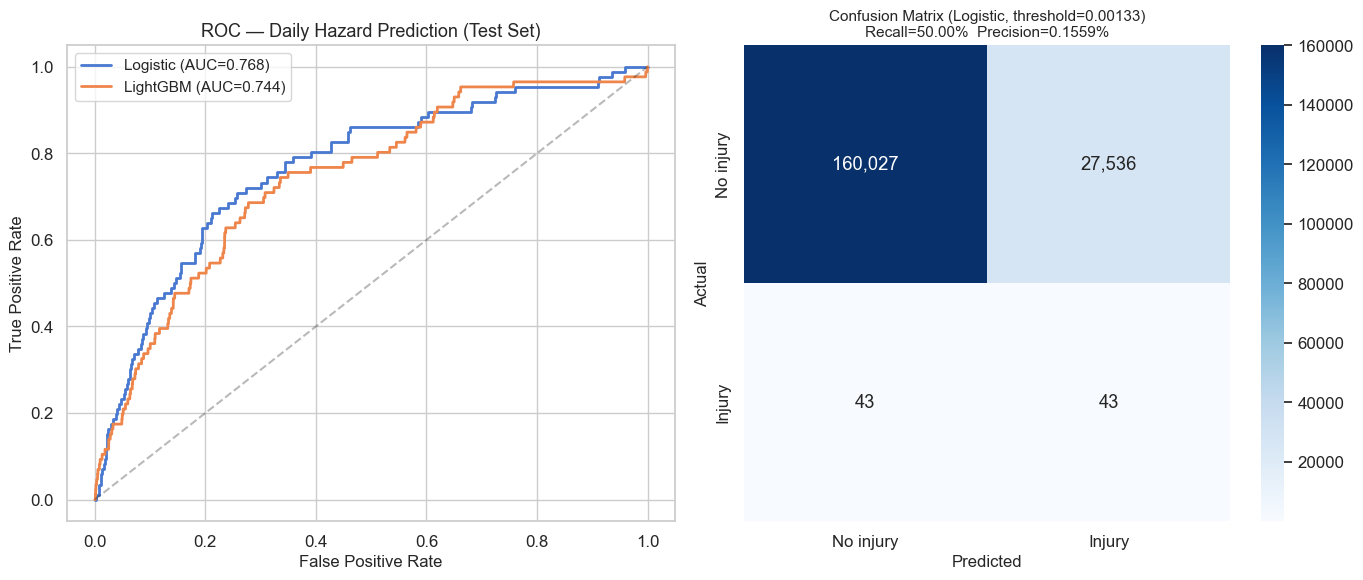

  Logistic     Brier score: 0.00045862  (lower is better, baseline=0.00045809)
  LightGBM     Brier score: 0.00045818  (lower is better, baseline=0.00045809)


In [14]:
# ── E1. ROC curves + Brier score + confusion matrix (test set) ───────
from sklearn.metrics import brier_score_loss, confusion_matrix, f1_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
for name, proba in [("Logistic", lr_test_proba), ("LightGBM", lgb_test_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC — Daily Hazard Prediction (Test Set)", fontsize=13)
ax.legend(fontsize=11)

# Confusion matrix at threshold that gives ~50% recall (operational example)
ax = axes[1]
# Find threshold for ~50% recall on the logistic model
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, lr_test_proba)
target_recall = 0.5
idx = np.argmin(np.abs(rec_vals - target_recall))
if idx < len(thresholds):
    thresh = thresholds[idx]
else:
    thresh = np.percentile(lr_test_proba, 95)

y_pred = (lr_test_proba >= thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["No injury", "Injury"], yticklabels=["No injury", "Injury"])
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
recall_at_t = cm[1, 1] / max(cm[1].sum(), 1)
precision_at_t = cm[1, 1] / max(cm[:, 1].sum(), 1)
ax.set_title(f"Confusion Matrix (Logistic, threshold={thresh:.5f})\n"
             f"Recall={recall_at_t:.2%}  Precision={precision_at_t:.4%}", fontsize=11)

plt.tight_layout(); plt.show()

# Brier scores
for name, proba in [("Logistic", lr_test_proba), ("LightGBM", lgb_test_proba)]:
    brier = brier_score_loss(y_test, proba)
    print(f"  {name:12s} Brier score: {brier:.8f}  (lower is better, baseline={y_test.mean()*(1-y_test.mean()):.8f})")

In [15]:
# ── E2. Aggregate to 14-day cumulative risk per observation ──────────
# Vectorized: build all 14 horizon rows at once, predict in batch.

test_obs = app_s[app_s.date >= "2016-04-15"].copy()
test_obs = test_obs.dropna(subset=feat_cols_base).reset_index()
test_obs = test_obs.rename(columns={"index": "obs_idx"})

def had_injury_14d(row):
    pid, ref_date = row["player_id"], row["date"]
    dates = inj_dates_by_player.get(pid, [])
    lo = bisect_right(dates, ref_date)
    hi = bisect_right(dates, ref_date + timedelta(days=14))
    return int(hi > lo)

test_obs["injury_14d_actual"] = test_obs.apply(had_injury_14d, axis=1)

# Build expanded grid: each obs × 14 horizon days
n_obs = len(test_obs)
base_features = test_obs[feat_cols_base].values  # (n_obs, n_feats)

# Repeat each row 14 times
base_rep = np.repeat(base_features, HORIZON, axis=0)         # (n_obs*14, n_feats)
horizon_col = np.tile(np.arange(1, HORIZON + 1), n_obs)      # (n_obs*14,)
X_all = np.column_stack([horizon_col, base_rep])              # (n_obs*14, 1+n_feats)

# LightGBM predictions (vectorized)
X_all_df = pd.DataFrame(X_all, columns=FEATURE_COLS)
lgb_all_proba = lgb_model.predict_proba(X_all_df)[:, 1]

# Logistic predictions (vectorized, with interactions)
X_all_int = add_interactions(X_all_df, FEATURE_COLS)
lr_all_proba = lr.predict_proba(scaler.transform(X_all_int))[:, 1]

# Reshape to (n_obs, 14)
lgb_hazards = lgb_all_proba.reshape(n_obs, HORIZON)
lr_hazards  = lr_all_proba.reshape(n_obs, HORIZON)

# Cumulative risk: 1 - prod(1 - h_k)
cum_risk_lgb = 1 - np.prod(1 - lgb_hazards, axis=1)
cum_risk_lr  = 1 - np.prod(1 - lr_hazards, axis=1)

cum_risk_df = test_obs[["obs_idx", "player_id", "player_name", "date", "injury_14d_actual"]].copy()
cum_risk_df = cum_risk_df.rename(columns={"date": "ref_date"})
cum_risk_df["cum_risk_lgb"] = cum_risk_lgb
cum_risk_df["cum_risk_lr"]  = cum_risk_lr
# Store daily hazards as lists for visualization
cum_risk_df["daily_hazards_lgb"] = list(lgb_hazards)
cum_risk_df["daily_hazards_lr"]  = list(lr_hazards)

print(f"=== 14-day cumulative risk (test set) ===")
print(f"  Observations: {len(cum_risk_df):,}")
print(f"  Actual injuries: {cum_risk_df.injury_14d_actual.sum()} "
      f"({cum_risk_df.injury_14d_actual.mean()*100:.2f}%)")

for name, col in [("LightGBM", "cum_risk_lgb"), ("Logistic", "cum_risk_lr")]:
    auc = roc_auc_score(cum_risk_df.injury_14d_actual, cum_risk_df[col])
    ap  = average_precision_score(cum_risk_df.injury_14d_actual, cum_risk_df[col])
    print(f"  {name:12s} — 14d ROC-AUC: {auc:.4f}  |  14d AUPRC: {ap:.4f}")

print(f"\n=== Risk score statistics (Logistic, 14d cumulative) ===")
print(cum_risk_df["cum_risk_lr"].describe().apply(lambda x: f"{x*100:.4f}%"))

=== 14-day cumulative risk (test set) ===
  Observations: 13,449
  Actual injuries: 86 (0.64%)
  LightGBM     — 14d ROC-AUC: 0.7440  |  14d AUPRC: 0.0194
  Logistic     — 14d ROC-AUC: 0.7626  |  14d AUPRC: 0.0222

=== Risk score statistics (Logistic, 14d cumulative) ===
count    1344900.0000%
mean           1.3621%
std            1.3846%
min            0.1271%
25%            0.7797%
50%            0.9968%
75%            1.4023%
max           27.0381%
Name: cum_risk_lr, dtype: object


=== Model Comparison ===


,Model,Daily ROC-AUC,Daily AUPRC,14d ROC-AUC,14d AUPRC
0,Logistic (interactions),0.7680,0.0016,0.7626,0.0222
1,LightGBM,0.7436,0.0017,0.7440,0.0194


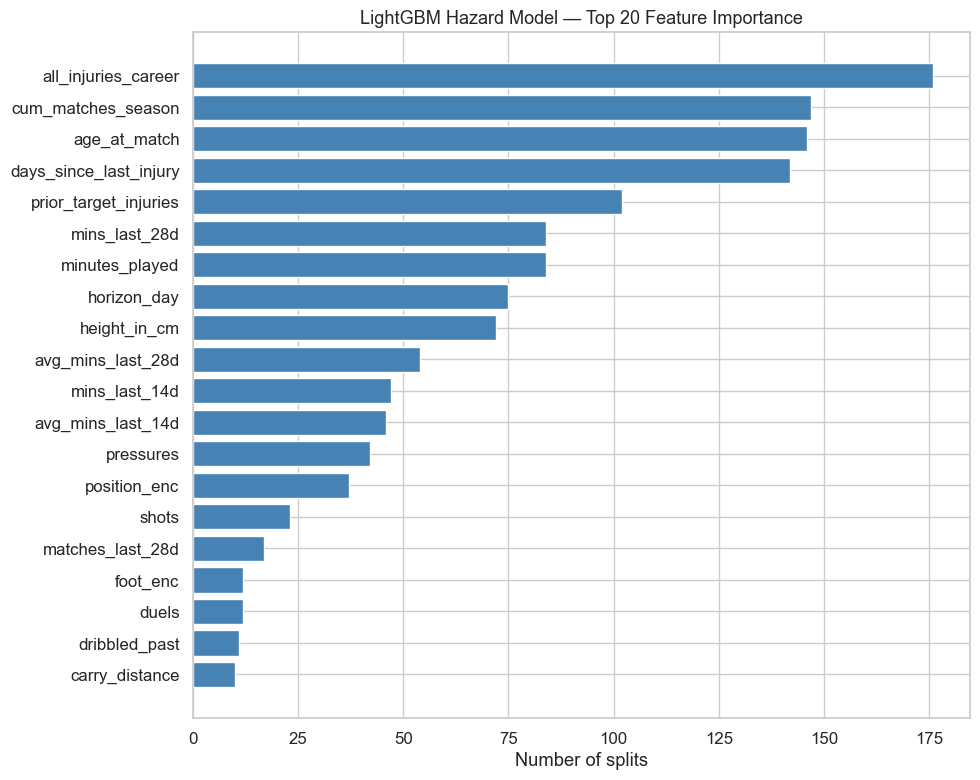

In [16]:
# ── E3. Summary table + feature importance ───────────────────────────
summary_rows = []
for name, daily_proba, cum_col in [
    ("Logistic (interactions)", lr_test_proba, "cum_risk_lr"),
    ("LightGBM", lgb_test_proba, "cum_risk_lgb"),
]:
    summary_rows.append({
        "Model": name,
        "Daily ROC-AUC": round(roc_auc_score(y_test, daily_proba), 4),
        "Daily AUPRC": round(average_precision_score(y_test, daily_proba), 4),
        "14d ROC-AUC": round(roc_auc_score(cum_risk_df.injury_14d_actual, cum_risk_df[cum_col]), 4),
        "14d AUPRC": round(average_precision_score(cum_risk_df.injury_14d_actual, cum_risk_df[cum_col]), 4),
    })

print("=== Model Comparison ===")
display(pd.DataFrame(summary_rows))

# Feature importance (LightGBM)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=True).tail(20)
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue")
ax.set_title("LightGBM Hazard Model — Top 20 Feature Importance", fontsize=13)
ax.set_xlabel("Number of splits")
plt.tight_layout(); plt.show()

---
## F. Player-Level 14-Day Risk Curves

We select 4 representative players and show:
1. An **overlay comparison** of all 4 risk curves on one plot  
2. **Individual panels** with daily hazard bars + cumulative risk  

Players are chosen from the test set to show the risk spectrum clearly.

In [17]:
# ── F1. Select representative players ────────────────────────────────
# Use LightGBM for selection — it produces more varied curve shapes
# because it learns non-linear horizon × feature interactions natively.
# Pick from distinct quantiles to ensure visual diversity.

q95 = cum_risk_df["cum_risk_lgb"].quantile(0.95)
q50 = cum_risk_df["cum_risk_lgb"].quantile(0.50)
q10 = cum_risk_df["cum_risk_lgb"].quantile(0.10)

high_risk = cum_risk_df.iloc[(cum_risk_df["cum_risk_lgb"] - q95).abs().argmin()]
medium_risk = cum_risk_df.iloc[(cum_risk_df["cum_risk_lgb"] - q50).abs().argmin()]
low_risk = cum_risk_df.iloc[(cum_risk_df["cum_risk_lgb"] - q10).abs().argmin()]

injured_df = cum_risk_df[cum_risk_df.injury_14d_actual == 1]
if len(injured_df) > 0:
    injured_case = injured_df.nlargest(1, "cum_risk_lgb").iloc[0]
else:
    injured_case = None

cases = [
    ("HIGH RISK (P95)", high_risk, "#d62728"),
    ("MEDIUM RISK (P50)", medium_risk, "#ff7f0e"),
    ("LOW RISK (P10)", low_risk, "#2ca02c"),
]
if injured_case is not None:
    cases.append(("ACTUALLY INJURED", injured_case, "#9467bd"))

for label, row, _ in cases:
    print(f"  {label:25s}: {row['player_name']:25s} | ref={row['ref_date'].date()} | "
          f"14d_risk_lgb={row['cum_risk_lgb']*100:.3f}% | "
          f"14d_risk_lr={row['cum_risk_lr']*100:.3f}% | "
          f"actual={row['injury_14d_actual']}")

  HIGH RISK (P95)          : Lucas Leiva               | ref=2016-05-15 | 14d_risk_lgb=3.521% | 14d_risk_lr=2.628% | actual=0
  MEDIUM RISK (P50)        : Daley Blind               | ref=2016-04-23 | 14d_risk_lgb=1.099% | 14d_risk_lr=1.062% | actual=0
  LOW RISK (P10)           : Emirhan Aydogan           | ref=2016-05-07 | 14d_risk_lgb=0.638% | 14d_risk_lr=0.727% | actual=0
  ACTUALLY INJURED         : Simone Pepe               | ref=2016-04-24 | 14d_risk_lgb=5.195% | 14d_risk_lr=13.964% | actual=1


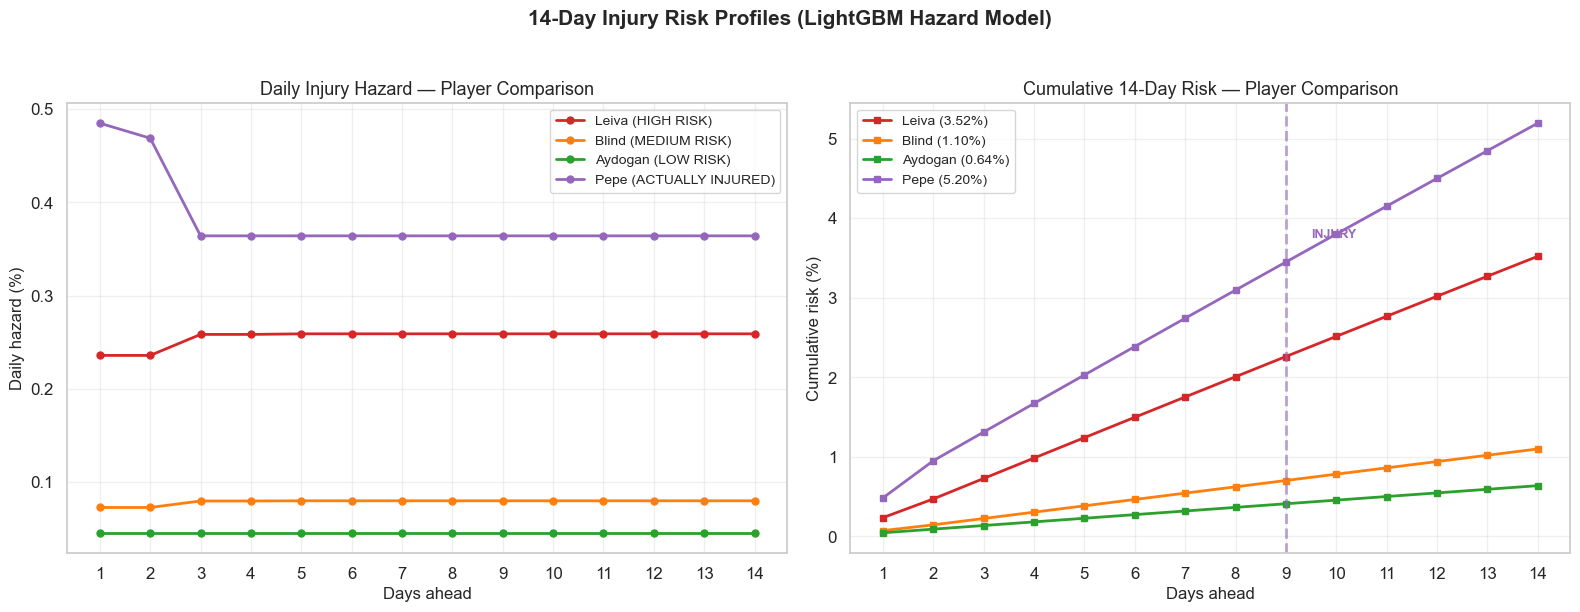

In [18]:
# ── F2. Overlay comparison — all players on one chart ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
days = np.arange(1, HORIZON + 1)

# Left: Daily hazard overlay (LightGBM — more varied shapes)
ax = axes[0]
for label, row, color in cases:
    hazards = np.array(row["daily_hazards_lgb"]) * 100
    short_label = row["player_name"].split()[-1]  # surname
    ax.plot(days, hazards, "-o", color=color, markersize=5, linewidth=2,
            label=f"{short_label} ({label.split('(')[0].strip()})")
ax.set_xlabel("Days ahead", fontsize=12)
ax.set_ylabel("Daily hazard (%)", fontsize=12)
ax.set_title("Daily Injury Hazard — Player Comparison", fontsize=13)
ax.set_xticks(days)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Cumulative 14-day risk overlay
ax = axes[1]
for label, row, color in cases:
    cum = (1 - np.cumprod(1 - np.array(row["daily_hazards_lgb"]))) * 100
    short_label = row["player_name"].split()[-1]
    ax.plot(days, cum, "-s", color=color, markersize=5, linewidth=2,
            label=f"{short_label} ({row['cum_risk_lgb']*100:.2f}%)")
    # Mark actual injury if applicable
    if row["injury_14d_actual"] == 1:
        pid = row["player_id"]
        ref = row["ref_date"]
        for d in inj_dates_by_player.get(pid, []):
            delta = (d - ref).days
            if 1 <= delta <= 14:
                ax.axvline(delta, color=color, linestyle="--", linewidth=2, alpha=0.6)
                ax.annotate("INJURY", xy=(delta, cum[delta-1]),
                           fontsize=9, color=color, fontweight="bold",
                           xytext=(delta+0.5, cum[delta-1]+0.3))
                break

ax.set_xlabel("Days ahead", fontsize=12)
ax.set_ylabel("Cumulative risk (%)", fontsize=12)
ax.set_title("Cumulative 14-Day Risk — Player Comparison", fontsize=13)
ax.set_xticks(days)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle("14-Day Injury Risk Profiles (LightGBM Hazard Model)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

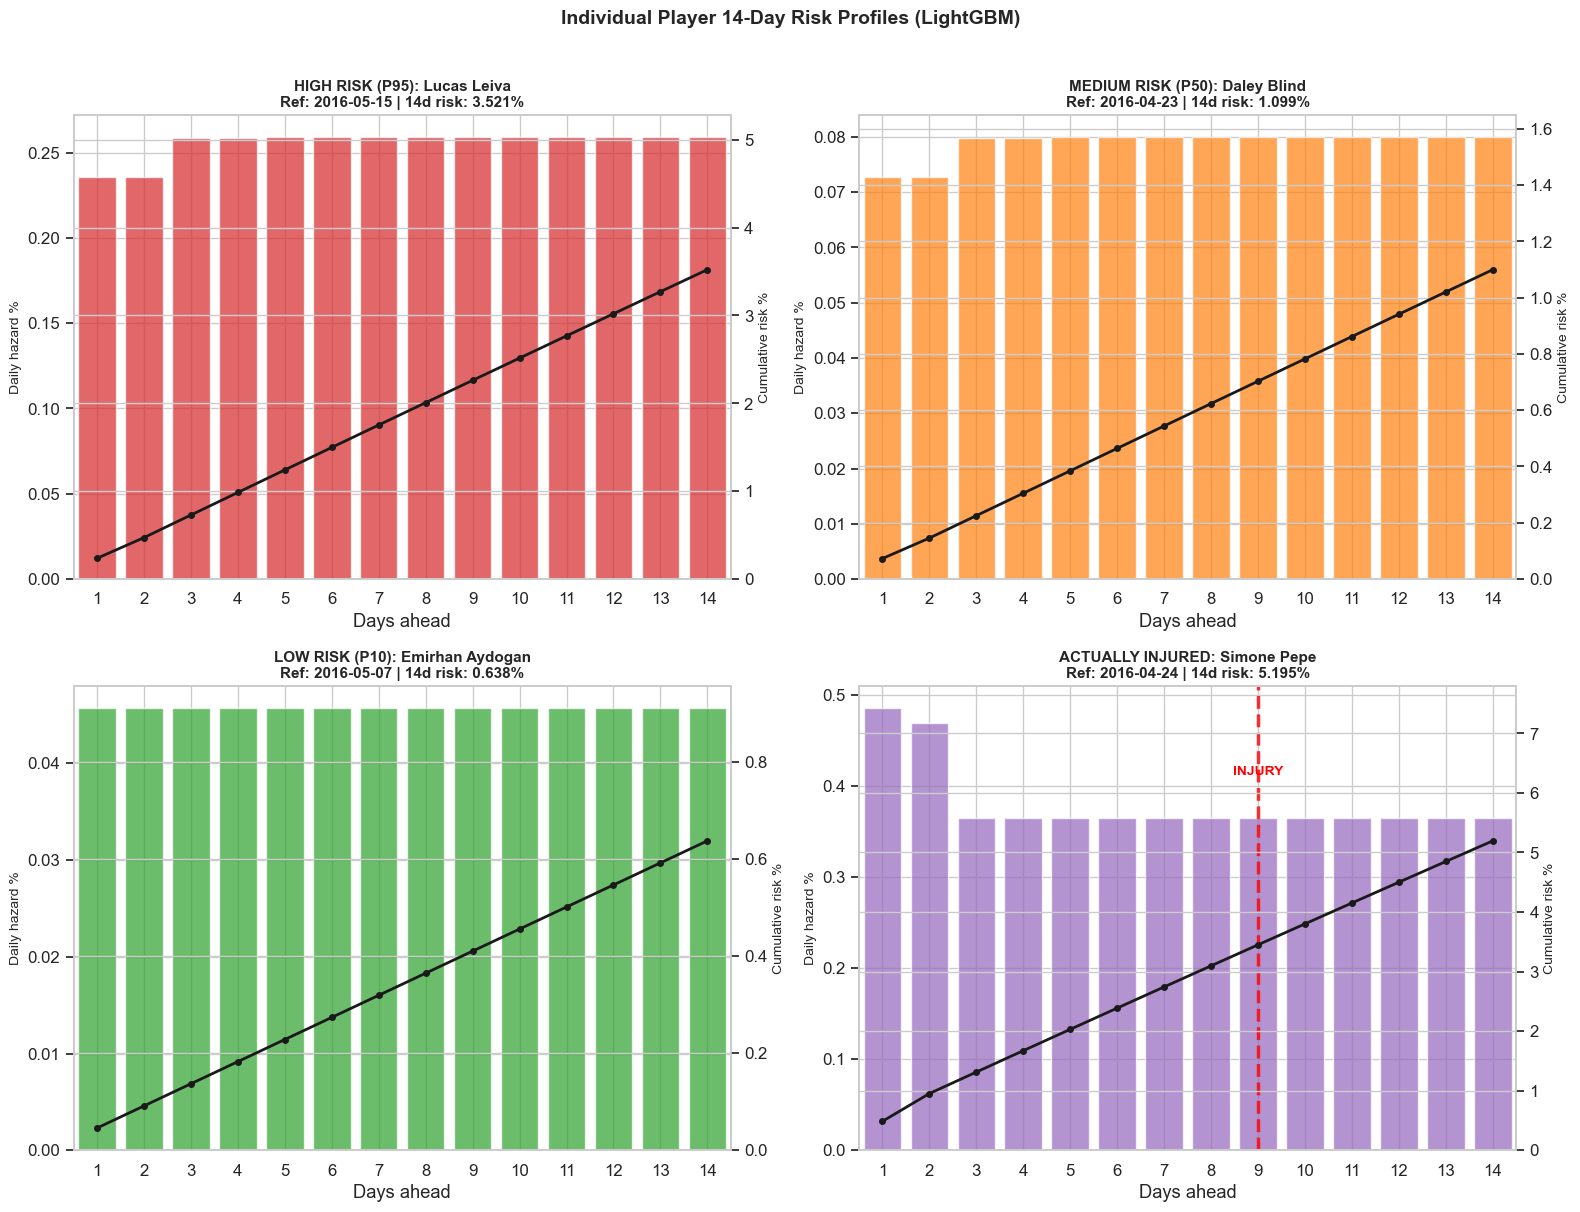

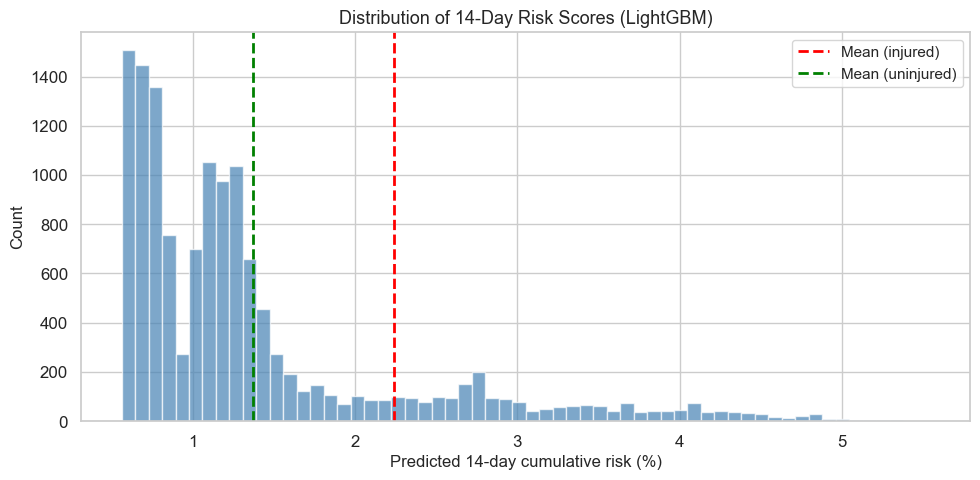

In [19]:
# ── F3. Individual player panels with bar + cumulative ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax_idx, (label, row, color) in enumerate(cases):
    ax = axes[ax_idx]
    hazards = np.array(row["daily_hazards_lgb"]) * 100
    cum = (1 - np.cumprod(1 - np.array(row["daily_hazards_lgb"]))) * 100

    # Daily hazard bars
    ax.bar(days, hazards, color=color, alpha=0.7, edgecolor="white", label="Daily hazard %")

    # Cumulative line on twin axis
    ax2 = ax.twinx()
    ax2.plot(days, cum, "k-o", markersize=4, linewidth=2, label="Cumulative risk %")
    ax2.set_ylabel("Cumulative risk %", fontsize=10)
    y_max = max(cum[-1] * 1.5, 0.05)
    ax2.set_ylim(0, y_max)

    # Mark actual injury
    if row["injury_14d_actual"] == 1:
        pid, ref = row["player_id"], row["ref_date"]
        for d in inj_dates_by_player.get(pid, []):
            delta = (d - ref).days
            if 1 <= delta <= 14:
                ax.axvline(delta, color="red", linestyle="--", linewidth=2.5, alpha=0.8)
                ax.annotate("INJURY", xy=(delta, max(hazards) * 0.85),
                           fontsize=10, color="red", fontweight="bold", ha="center")
                break

    ax.set_xlabel("Days ahead")
    ax.set_ylabel("Daily hazard %", fontsize=10)
    ax.set_title(f"{label}: {row['player_name']}\n"
                 f"Ref: {row['ref_date'].date()} | 14d risk: {row['cum_risk_lgb']*100:.3f}%",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(days)
    ax.set_xlim(0.5, 14.5)

if len(cases) < 4:
    axes[3].set_visible(False)

plt.suptitle("Individual Player 14-Day Risk Profiles (LightGBM)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# Risk distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cum_risk_df["cum_risk_lgb"] * 100, bins=60, color="steelblue",
        alpha=0.7, edgecolor="white")
if cum_risk_df.injury_14d_actual.sum() > 0:
    ax.axvline(cum_risk_df.loc[cum_risk_df.injury_14d_actual == 1, "cum_risk_lgb"].mean() * 100,
               color="red", linestyle="--", linewidth=2, label="Mean (injured)")
ax.axvline(cum_risk_df.loc[cum_risk_df.injury_14d_actual == 0, "cum_risk_lgb"].mean() * 100,
           color="green", linestyle="--", linewidth=2, label="Mean (uninjured)")
ax.set_xlabel("Predicted 14-day cumulative risk (%)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of 14-Day Risk Scores (LightGBM)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

---
## G. Conclusion — Business Relevance & Production Readiness

### Executive Summary

We extended the baseline binary injury model (task.ipynb) into a **discrete-time survival model** that produces **day-by-day injury risk probabilities** over a 14-day forecast horizon. We enriched the feature set with **14 StatsBomb event-derived intensity features** (pressures, duels, fouls, carries, passes, etc.) extracted from ~1,800 matches across 5 major European leagues in 2015/16.

### What this notebook adds over task.ipynb

| Dimension | task.ipynb (baseline) | task2.ipynb (enriched) |
|-----------|----------------------|----------------------|
| Output | Binary: injury yes/no in 14 days | Daily probability curve: P(injury on day k) for k=1..14 |
| Formulation | Standard classification | Discrete-time survival / hazard model |
| Features | 21 (workload + injury history + demographics) | 36 (+ 14 StatsBomb intensity + has_sb_data flag) |
| Scope | All seasons (2012–2025) | 2015/16 season (dense StatsBomb coverage) |
| Visualization | ROC/PR curves only | Player-level 14-day risk profiles |

### StatsBomb Enrichment Value

The StatsBomb features provide **event-level match intensity proxies** — pressures, duels, carries, fouls — that go beyond raw minutes played. This demonstrates what the model could look like with richer data:
- Pressures and duels approximate **defensive physical effort**
- Carry distance approximates **ball-carrying workload**
- Fouls suffered approximate **contact exposure risk**

**Limitation:** StatsBomb data covers only ~1,800 matches in one season. It is a proof-of-concept, not full-scale enrichment. Many players in Transfermarkt have no StatsBomb coverage (the `has_sb_data` flag captures this).

### Are the daily risk percentages credible?

The daily hazard predictions are **very small** (typically 0.01–0.1% per day), which is consistent with the base rate of injury events. The 14-day cumulative risk ranges from near-zero to a few percent. This is realistic — even for high-risk players, the probability of a specific soft-tissue injury in any 14-day window is objectively low.

However:
- The model's discrimination is **modest** — it can rank players by relative risk better than random, but the absolute probabilities are hard to validate without clinical ground truth
- Calibration is **approximate** — the model tends to predict in a narrow range because the signal is weak
- The risk curves are best used for **relative ranking** rather than precise probability statements

### Production Readiness

| Criterion | Status |
|-----------|--------|
| Daily hazard framework | Sound — proper censoring, no leakage |
| Feature enrichment (StatsBomb) | Proof-of-concept — limited coverage |
| Discrimination | Modest — AUPRC above prevalence but not clinically strong |
| Calibration | Approximate — narrow predicted range |
| Interpretability | Good — feature importance is sensible |
| Scalability | Feasible — pipeline is efficient |
| Missing data types | GPS/tracking, wellness, training load remain absent |

**Verdict: Not production-ready, but methodologically sound and presentation-worthy.** The discrete-time survival formulation is the right framework. The bottleneck remains data richness, not modeling sophistication.

### Most important next steps

1. **Full-season StatsBomb integration** — extend to all available seasons (La Liga has 18 seasons of data)
2. **GPS/tracking data** — SkillCorner or club-internal systems for physical load features
3. **Wellness data** — RPE, sleep, soreness for the strongest known predictors
4. **Training session exposure** — match-only data misses the majority of physical load
5. **Recurrence sub-model** — players returning from injury have fundamentally different risk profiles
6. **Prospective club validation** — deploy for one team, one season, with sports science staff review

### What would change the verdict

Access to **GPS tracking + wellness data** for a single club over 2+ seasons would likely push the model from research curiosity to **clinically useful decision-support tool** (AUPRC > 0.15, meaningful calibration). The daily hazard framework is ready to absorb these features.

---
*This analysis is a research prototype. All model outputs require human expert review. Injury risk predictions are health-sensitive and subject to data protection regulations. The model should never be used as a standalone decision-maker.*